In [1]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import sys 

import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
import generate_data
from datasets import LetterStringDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Batching Illustration

In [2]:
ds = LetterStringDataset(mode="val", data_dir="../data/all_transformations_study1", batch_size=4, batching_method="both", query_first=False)
# alternative values for batching_method: "unstructured", "alphabet", "transformation", query_first can be True or False
dataloader = DataLoader(ds, batch_sampler=ds.sampler, collate_fn=ds.collate_fn)

In [3]:
# print first 6 batches
for i, batch in enumerate(dataloader):
    if i > 5:
        break
    print(f"\n\nBatch {i+1}")
    for i in range(len(batch["xq_context"])):
        print(f"[{batch["transformation"][i]}], [{batch["alphabet"][i]}]")
        print(f"{" ".join(batch["xq_context"][i])}\n")



Batch 1
[fix_alphabetic_seq], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SOS b n o p q r IO m n o p q r SOS a x c u

[fix_alphabetic_seq], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SOS o n q r s t IO o p q r s t SOS f o p q r s t

[fix_alphabetic_seq], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SOS a x c u IO a b c u SOS p q r c t

[fix_alphabetic_seq], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SOS u e a g h IO u e f g h SOS k d v



Batch 2
[fix_pred_succ], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SOS n o p q m s t IO m o p q m s d SOS h i z k l

[fix_pred_succ], [a b c u e f g h i j k l m n o p q r s t d v w x y z]
a b c u e f g h i j k l m n o p q r s t d v w x y z SO

## Batching Results

In [4]:
unstructured = CheckPoint.from_pt(path="../models/MLC_batchunstruct_dallstudy1_nep20.pt")
unstructured_query_first = CheckPoint.from_pt(path="../models/MLC_batchunstruct_qf_dallstudy1_nep20.pt")
by_trans = CheckPoint.from_pt(path="../models/MLC_batchbytrans_dallstudy1_nep20.pt")
by_alph = CheckPoint.from_pt(path="../models/MLC_batchbyalph_dallstudy1_nep20.pt")
by_both = CheckPoint.from_pt(path="../models/MLC_batchbyboth_dallstudy1_nep20.pt")
all_training_runs = [unstructured, unstructured_query_first, by_trans, by_alph, by_both]

In [5]:
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["loss"] = round(train_run.best_val_loss, 3)
    data[i]["accuracy in-dist"] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["accuracy out-of-dist"] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
df = pd.DataFrame(data)
print("Shared Training Configuration:")
shared_arguments = df.loc[:, df.nunique() == 1].drop(["dir_model", "save_best", "save_best_skip"], axis=1).rename(columns={"dir_data": "dataset"})
shared_arguments.loc[0,:].to_markdown("table_batching_shared_params.md")
shared_arguments.loc[0,:]

Shared Training Configuration:


dataset            data/all_transformations_study1
batch_size                                      32
nepochs                                         20
lr                                           0.001
lr_end_factor                                 0.05
lr_warmup                                     True
hidden_size                                    128
input_size                                      30
output_size                                     30
PAD_idx_input                                   28
PAD_idx_output                                  28
nlayers_encoder                                  3
nlayers_decoder                                  3
nhead                                            8
dropout_p                                      0.1
ff_mult                                          4
activation                                    gelu
Name: 0, dtype: object

In [6]:
print("Differences in Configuration and Resuls:")
df.loc[:, df.nunique() > 1].to_markdown("table_batching.md", index=False) # save results table
df.loc[:, df.nunique() > 1]

Differences in Configuration and Resuls:


,filename_model,batching_method,query_first,loss,accuracy in-dist,accuracy out-of-dist
0,MLC_batchunstruct_dallstudy1_nep20.pt,unstructured,False,1.079,0.680,0.118
1,MLC_batchunstruct_qf_dallstudy1_nep20.pt,unstructured,True,1.090,0.623,0.086
2,MLC_batchbytrans_dallstudy1_nep20.pt,transformation,False,1.203,0.640,0.121
3,MLC_batchbyalph_dallstudy1_nep20.pt,alphabet,False,1.112,0.618,0.084
4,MLC_batchbyboth_dallstudy1_nep20.pt,both,False,1.257,0.602,0.098


## Easier Validation Set
- queries that appear in the training set can reappear in the validation/test sets but paired with new study examples

In [7]:
easier_val = CheckPoint.from_pt(path="../models/MLC_all_trans_study1_nep20_lr0_0005_bs64_dr0_2_io_easy_val.pt")

In [8]:
print("Easier Validation set")
print(f"Best Val Loss: {round(easier_val.best_val_loss, 3)}")
print(f"Best Val Acc (in-dist): {round(np.max([x["in"] for x in easier_val.val_acc_hist]), 3)}")
print(f"Best Val Acc (out-of-dist): {round(np.max([x["out-of"] for x in easier_val.val_acc_hist]), 3)}")

Easier Validation set
Best Val Loss: 1.017
Best Val Acc (in-dist): 0.774
Best Val Acc (out-of-dist): 0.128


In [9]:
model = easier_val.load_model()
val = easier_val.load_dataloaders("../data/all_transformations_study1_easier_val", use_datasets=["val"])[0]

Loading model that has completed 21 of 20 epochs
	batch size: 64
	number of steps: 57,520
	best val loss achieved: 1.0168
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.2 dropout
Loaded following dataloaders:
val dataloader (n=39,058)


Training information:
Best Validation Loss: 1.017
Best Validation Accuracy: 0.461


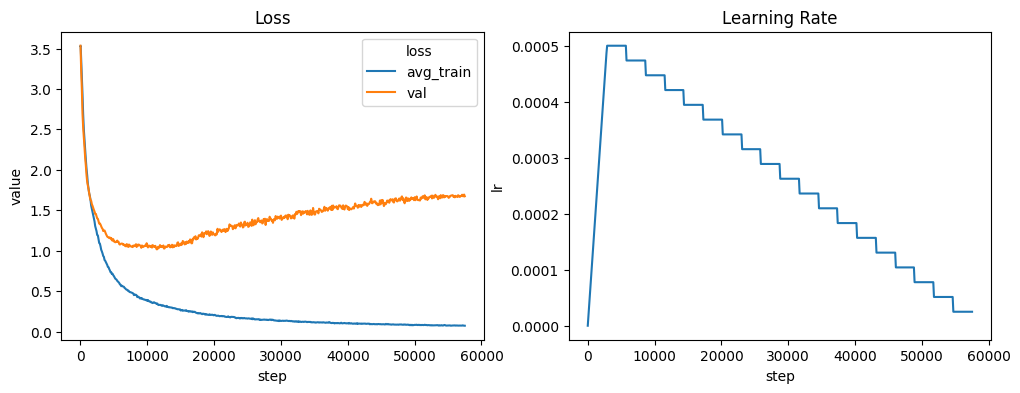

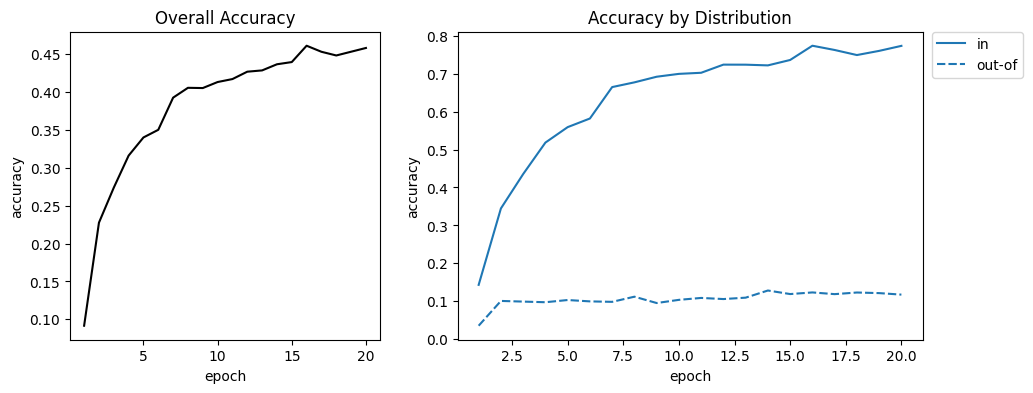

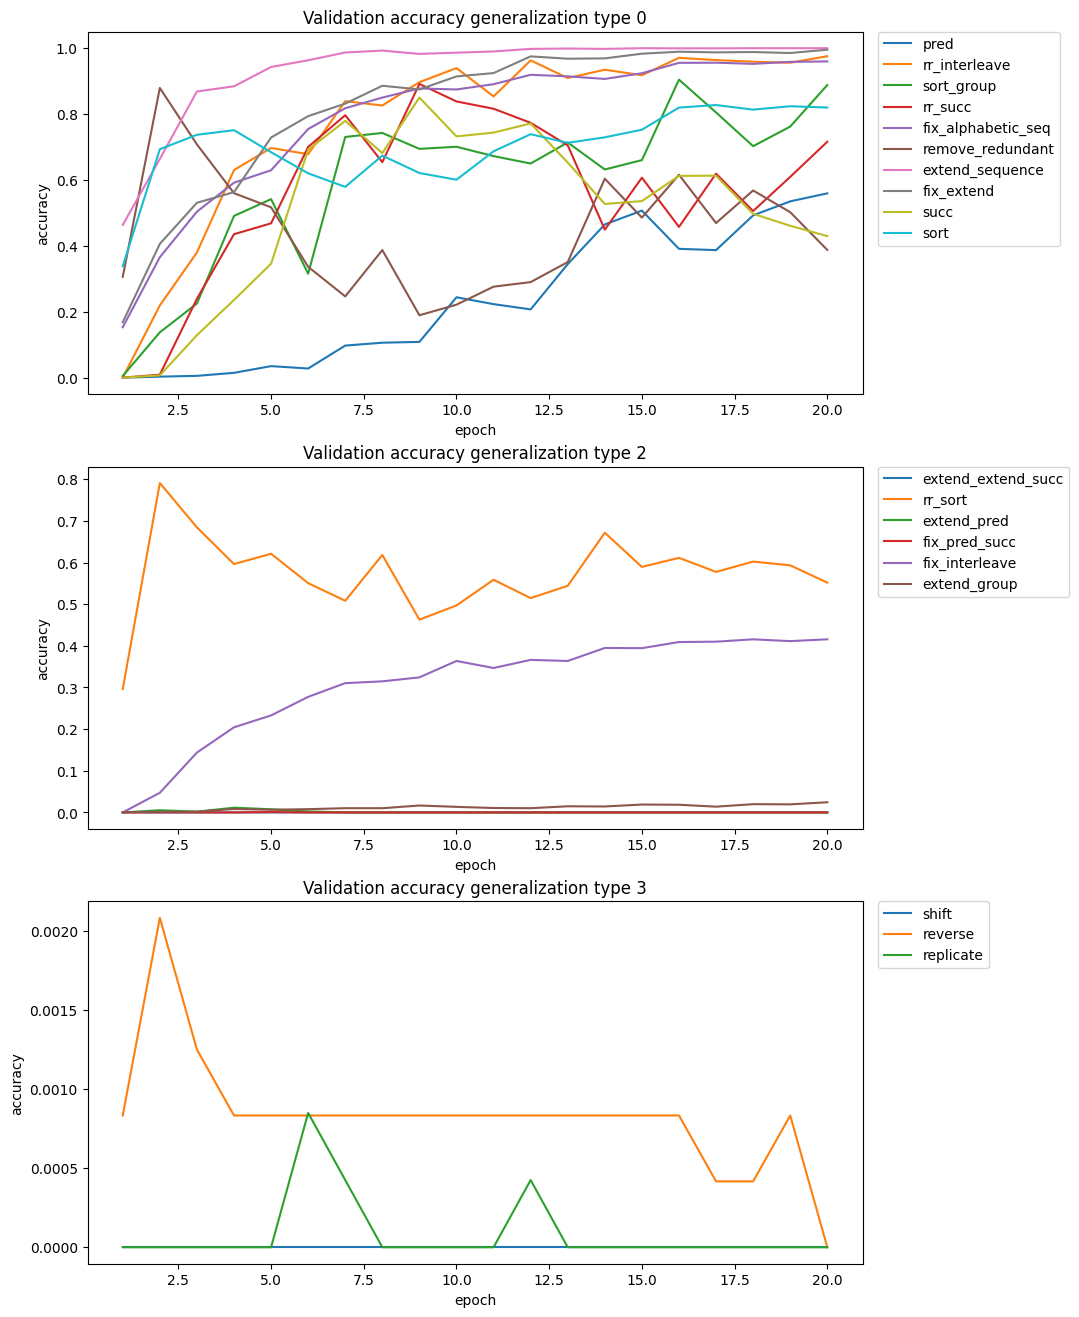

In [10]:
_ = analysis_utils.training_information(easier_val, val)

## Dataset that includes "copy"
- For half of the examples, the model can just copy the answer from the study example since the query and the study example are the same

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loaded following dataloaders:
val dataloader (n=45,901)
Training information:
Best Validation Loss: 0.721
Best Validation Accuracy: 0.641


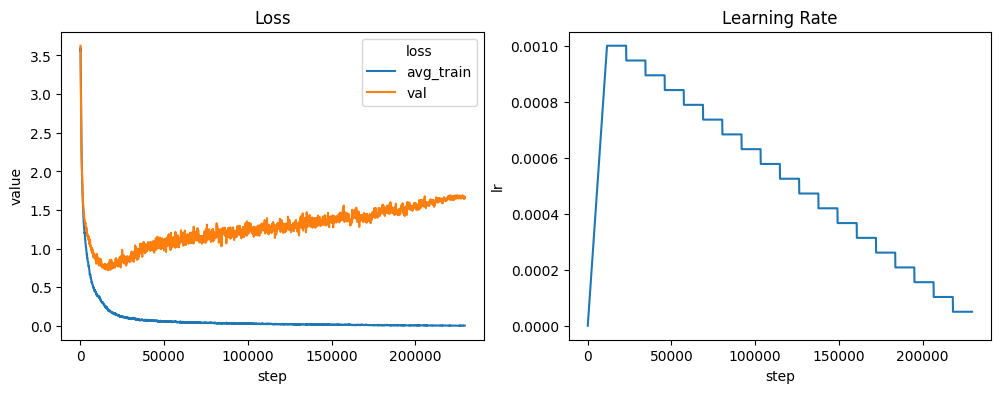

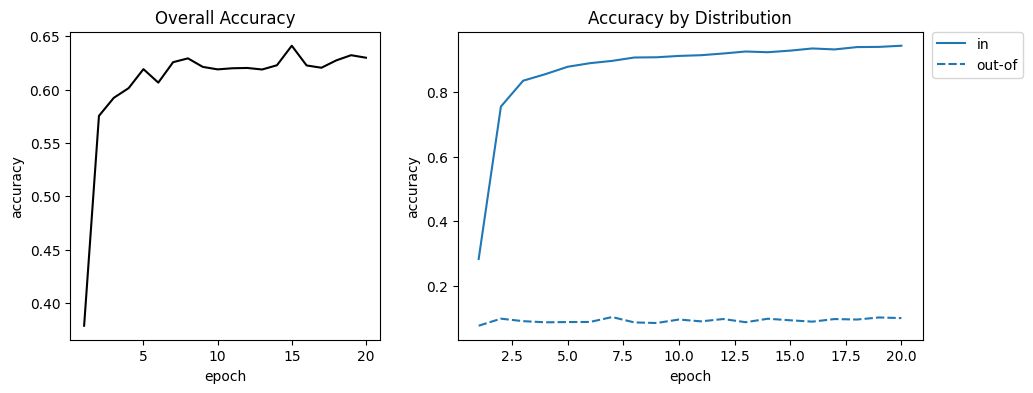

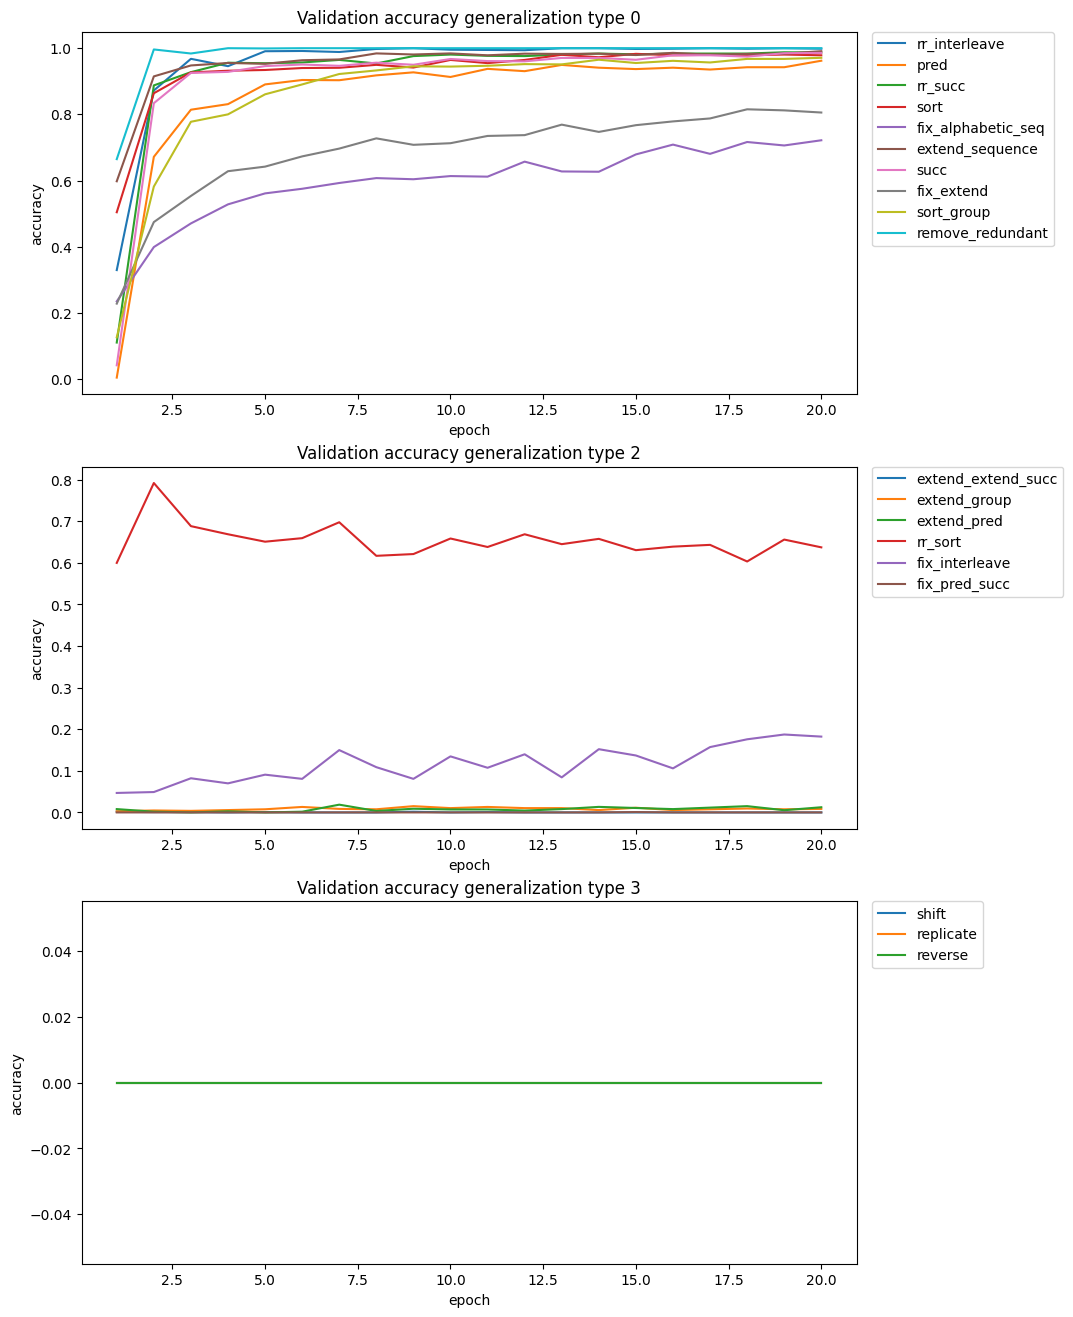

In [11]:
cp_v2 = CheckPoint.from_pt("../models/MLC_batchunstruct_dallstudy1copy_nep20_checkpoint-v2.pt")
model = cp_v2.load_model()
val = cp_v2.load_dataloaders("../data/all_transformations_study1_incl_copy", val_batch_size=5000, use_datasets=["val"])[0]
_ = analysis_utils.training_information(cp_v2, val)

In [12]:
pred = analysis_utils.predict_dataset(val, model, alternative_rule_errors=False)

Predicting:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\13579681\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Predicting: 10it [13:53, 83.38s/it]                       


In [ ]:
copy_accs = dict()
copy_accs["overall"] = np.mean(pred.correct)

pred_noncopy = pred[~pred["copy"]]
pred_copy = pred[pred["copy"]]
copy_accs["noncopy"] = np.mean(pred_noncopy.correct)
copy_accs["noncopy in-dist (rules in train set)"] = np.mean(pred_noncopy[pred_noncopy.distribution == "in"]["correct"])
copy_accs["copy in-dist (rules in train set)"] = np.mean(pred_copy[pred_copy["distribution"]=="in"]["correct"])
copy_accs["noncopy out-of-dist (rules NOT in train set)"] = np.mean(pred_noncopy[pred_noncopy.distribution == "out-of"]["correct"])
copy_accs["copy out-of-dist (rules NOT in train set)"] = np.mean(pred_copy[pred_copy["distribution"]=="out-of"]["correct"])
generalization_t2 = [key for key, value in generate_data.STD_GENERALIZATION_TYPES.items() if value==2]
pred_gen_t2 = pred_noncopy[pred_noncopy["transformation"].isin(generalization_t2)]
copy_accs["noncopy (generalization type 2)"] = np.mean(pred_gen_t2.correct)
copy_accs["noncopy by transformation type"] = pred_noncopy.groupby("transformation")["correct"].mean()

In [14]:
print("Validation Accuracies from training with copy tasks (query is the same as study example)\n-------------------------------------------------------------------------------------------")
for key, value in copy_accs.items():
    if key != "noncopy by transformation type":
        print(f"{key}: {value:.3f}")

print("\nValidation Accuracies noncopy by transformation type:\n-------------------------------------------------------------------------------------------")
print(copy_accs["noncopy by transformation type"].round(3))

Validation Accuracies from training with copy tasks (query is the same as study example)
-------------------------------------------------------------------------------------------
overall: 0.630
noncopy: 0.568
noncopy in-dist (rules in train set): 0.943
copy in-dist (rules in train set): 0.995
noncopy out-of-dist (rules NOT in train set): 0.100
copy out-of-dist (rules NOT in train set): 0.318
noncopy (generalization type 2): 0.146

Validation Accuracies noncopy by transformation type:
-------------------------------------------------------------------------------------------
transformation
extend_extend_succ    0.000
extend_group          0.008
extend_pred           0.012
extend_sequence       0.991
fix_alphabetic_seq    0.722
fix_extend            0.806
fix_interleave        0.183
fix_pred_succ         0.000
pred                  0.962
remove_redundant      1.000
replicate             0.000
reverse               0.000
rr_interleave         0.998
rr_sort               0.637
rr_succ   

In [15]:
train = pd.read_csv(f"../{cp_v2.train_config.dir_data}/train.csv")
val = pd.read_csv(f"../{cp_v2.train_config.dir_data}/val.csv")

unique_problems_train = set(train.problem)
unique_problems_val = set(val.problem)
unique_problems_train & unique_problems_val

set()

### Evaluating on the test set (TO DO)

In [16]:
# TODO: need to recover alphabets from .json files in Martha's github
import pandas as pd
import ast
df = pd.read_csv("https://raw.githubusercontent.com/marthaflinderslewis/counterfactual_analogy/refs/heads/main/data/data.csv")

In [17]:
df.head()

,subj_id,model,promptstyle,nperms,alph,prob_type,prob_ind,response_string,source_1,source_2,target_1,correct_answer,given_answer,correct,total
0,1,human,human,np_10,alph_1,succ,4.0,gyik,"['x', 'p', 'h', 'r']","['x', 'p', 'h', 's']","['g', 'y', 'i', 'o']","['g', 'y', 'i', 'k']","['g', 'y', 'i', 'k']",True,1
1,1,human,human,np_10,alph_5,add_letter,9.0,fgrij,"['q', 'l', 's', 't']","['q', 'l', 's', 't', 'u']","['f', 'g', 'r', 'i']","['f', 'g', 'r', 'i', 'j']","['f', 'g', 'r', 'i', 'j']",True,1
2,1,human,human,np_10,alph_3,attn,9.0,aaaa,"['t', 'u', 'v', 'w']","['t', 'u', 'v', 'x']","['m', 'c', 'p', 'z']","['a', 'a', 'a', 'a']","['a', 'a', 'a', 'a']",True,1
3,1,human,human,np_10,alph_0,fix_alphabet,3.0,elgai,"['k', 'r', 'm', 'u', 'f']","['k', 'l', 'm', 'u', 'f']","['e', 'o', 'g', 'a', 'i']","['e', 'o', 'g', 'h', 'i']","['e', 'l', 'g', 'a', 'i']",False,1
4,1,human,human,np_10,alph_2,remove_redundant,7.0,vhefg,"['x', 'x', 'a', 'w', 'i', 'z']","['x', 'a', 'w', 'i', 'z']","['v', 'h', 'h', 'e', 'f', 'g']","['v', 'h', 'e', 'f', 'g']","['v', 'h', 'e', 'f', 'g']",True,1


In [18]:
df.source_1 = df.source_1.apply(lambda x: ast.literal_eval(x))
df.source_2 = df.source_2.apply(lambda x: ast.literal_eval(x))
df.target_1 = df.target_1.apply(lambda x: ast.literal_eval(x))
df.correct_answer = df.correct_answer.apply(lambda x: ast.literal_eval(x))

In [19]:
df.query_length = df.target_1.apply(lambda x: len(x))

C:\Users\13579681\AppData\Local\Temp\ipykernel_20144\3386814706.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.query_length = df.target_1.apply(lambda x: len(x))
